***GROUP 12 MEMBERS***
* **JUMA CLINI BENSON      SCT213-C002-0120/2024**
* **MILANETTO DANIEL       SCT213-C002-0010/2024**
* **ABDULLAHI YUSSUF       SCT213-C002-0132/2024**
* **MIKE GITONGA           SCT213-C002-0011/2024**
* **AHMED IBRAHIM          SCT213-C002-0100/2024**

***MUTIVARIATE ANALYSIS AND PREDICTION OF CH₄(METHANE) AND N₂O(NITROUS OXIDE) EMISSIONS ACROSS COUNTRIES***
* How do CH₄ and N₂O emissions vary across countries and world regions, and how effectively can emission reduction status—defined as a binary indicator of whether a country has reduced emissions since 1990—be predicted using per-capita emissions and geographic classification?

In [384]:
#importing tidyverse library to enable data acquisition ,data manipulation and visualization through its packages
library(tidyverse)

In [385]:
#Data Acquisition
df <- read.csv("CH4_N2O_Emissions.csv", 
               stringsAsFactors = FALSE,
               na.strings = c("...", "", "NA")) %>%
  as_tibble()

In [386]:
df

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,X..change.since.1990,N2O.emissions,N2O.emissions.per.capita,X..change.since.1990.1,X
<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>
Afghanistan,2005,10.16,0.42,NA,5.94,0.24,NA,NA
Albania,1994,2.14,0.68,NA,0.29,0.09,NA,NA
Algeria,2000,32.92,1.06,NA,6.50,0.21,NA,NA
Angola,2005,19.93,1.11,NA,13.87,0.77,NA,NA
Antigua and Barbuda,2000,0.14,1.83,43.74,0.08,1.08,5197.47,NA
Argentina,2000,84.85,2.29,10.50,67.50,1.82,30.26,NA
Armenia,2010,2.26,0.76,-28.66,0.48,0.16,185.46,NA
Australia,2012,111.71,4.88,-3.02,25.78,1.13,40.43,NA
Austria,2012,5.31,0.63,-36.32,5.22,0.62,-15.75,NA


In [387]:
head(df)

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,X..change.since.1990,N2O.emissions,N2O.emissions.per.capita,X..change.since.1990.1,X
<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>
Afghanistan,2005,10.16,0.42,NA,5.94,0.24,NA,NA
Albania,1994,2.14,0.68,NA,0.29,0.09,NA,NA
Algeria,2000,32.92,1.06,NA,6.50,0.21,NA,NA
Angola,2005,19.93,1.11,NA,13.87,0.77,NA,NA
Antigua and Barbuda,2000,0.14,1.83,43.74,0.08,1.08,5197.47,NA
Argentina,2000,84.85,2.29,10.50,67.50,1.82,30.26,NA


In [388]:
tail(df)

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,X..change.since.1990,N2O.emissions,N2O.emissions.per.capita,X..change.since.1990.1,X
<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA


In [389]:
#Data Schema and variable definitions
dim(df)

[1] 204   9

In [390]:
#Columns
names(df)

[1] "Country"                  "latest.year.available"   
[3] "CH4.emissions"            "CH4.emissions.per.capita"
[5] "X..change.since.1990"     "N2O.emissions"           
[7] "N2O.emissions.per.capita" "X..change.since.1990.1"  
[9] "X"

In [391]:
#data types and internal structure
glimpse(df)

Rows: 204
Columns: 9
$ Country                  <chr> "Afghanistan", "Albania", "Algeria", "Angola"…
$ latest.year.available    <int> 2005, 1994, 2000, 2005, 2000, 2000, 2010, 201…
$ CH4.emissions            <dbl> 10.16, 2.14, 32.92, 19.93, 0.14, 84.85, 2.26,…
$ CH4.emissions.per.capita <dbl> 0.42, 0.68, 1.06, 1.11, 1.83, 2.29, 0.76, 4.8…
$ X..change.since.1990     <dbl> NA, NA, NA, NA, 43.74, 10.50, -28.66, -3.02, …
$ N2O.emissions            <chr> "5.94", "0.29", "6.50", "13.87", "0.08", "67.…
$ N2O.emissions.per.capita <chr> "0.24", "0.09", "0.21", "0.77", "1.08", "1.82…
$ X..change.since.1990.1   <chr> NA, NA, NA, NA, "5197.47", "30.26", "185.46",…
$ X                        <lgl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, N…


In [398]:
df$CH4.emissions <- parse_double(df$CH4.emissions)
df$N2O.emissions <- parse_double(df$N2O.emissions)
df$X..change.since.1990.1 <- parse_double(df$X..change.since.1990.1)
df %>%
  summarise(across(where(is.numeric), mean, na.rm = TRUE))

ERROR: Error in parse_vector(x, col_double(), na = na, locale = locale, trim_ws = trim_ws): is.character(x) is not TRUE


In [399]:
#Type Casting
#Converting data type of N20.emissions from character to double for numerical operations
df$N2O.emissions <- as.double(df$N2O.emissions)

In [400]:
#Converting data type of N20.emissions.per.capita from character to double for numerical operations
df$N2O.emissions.per.capita <- as.double(df$N2O.emissions.per.capita)

In [401]:
#Converting data type of N20.emissions.per.capita from character to double for numerical operations
df$X..change.since.1990.1 <- as.double(df$X..change.since.1990.1)

In [402]:
#position of the first duplicated value
anyDuplicated(df)

[1] 186

In [403]:
#total no. of duplicated rows
sum(duplicated(df))

[1] 19

In [404]:
df[duplicated(df), ]

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,X..change.since.1990,N2O.emissions,N2O.emissions.per.capita,X..change.since.1990.1,X
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA


In [405]:
#remove duplicated rows
df <- unique(df)

In [406]:
df

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,X..change.since.1990,N2O.emissions,N2O.emissions.per.capita,X..change.since.1990.1,X
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
Afghanistan,2005,10.16,0.42,NA,5.94,0.24,NA,NA
Albania,1994,2.14,0.68,NA,0.29,0.09,NA,NA
Algeria,2000,32.92,1.06,NA,6.50,0.21,NA,NA
Angola,2005,19.93,1.11,NA,13.87,0.77,NA,NA
Antigua and Barbuda,2000,0.14,1.83,43.74,0.08,1.08,5197.47,NA
Argentina,2000,84.85,2.29,10.50,67.50,1.82,30.26,NA
Armenia,2010,2.26,0.76,-28.66,0.48,0.16,185.46,NA
Australia,2012,111.71,4.88,-3.02,25.78,1.13,40.43,NA
Austria,2012,5.31,0.63,-36.32,5.22,0.62,-15.75,NA


In [407]:
df <- df[-nrow(df), ]

In [408]:
df

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,X..change.since.1990,N2O.emissions,N2O.emissions.per.capita,X..change.since.1990.1,X
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
Afghanistan,2005,10.16,0.42,NA,5.94,0.24,NA,NA
Albania,1994,2.14,0.68,NA,0.29,0.09,NA,NA
Algeria,2000,32.92,1.06,NA,6.50,0.21,NA,NA
Angola,2005,19.93,1.11,NA,13.87,0.77,NA,NA
Antigua and Barbuda,2000,0.14,1.83,43.74,0.08,1.08,5197.47,NA
Argentina,2000,84.85,2.29,10.50,67.50,1.82,30.26,NA
Armenia,2010,2.26,0.76,-28.66,0.48,0.16,185.46,NA
Australia,2012,111.71,4.88,-3.02,25.78,1.13,40.43,NA
Austria,2012,5.31,0.63,-36.32,5.22,0.62,-15.75,NA


In [409]:
#Data Quality Assessment to check missing values
colSums(is.na(df))

Country    latest.year.available            CH4.emissions 
                       0                        0                        0 
CH4.emissions.per.capita     X..change.since.1990            N2O.emissions 
                       1                       98                        2 
N2O.emissions.per.capita   X..change.since.1990.1                        X 
                       2                       99                      184

In [410]:
#percentage missing values
round(colMeans(is.na(df)) * 100, 2)

Country    latest.year.available            CH4.emissions 
                    0.00                     0.00                     0.00 
CH4.emissions.per.capita     X..change.since.1990            N2O.emissions 
                    0.54                    53.26                     1.09 
N2O.emissions.per.capita   X..change.since.1990.1                        X 
                    1.09                    53.80                   100.00

In [411]:
#Remove column "X" since it is fully null
df <- df[, colMeans(is.na(df)) < 1]

In [412]:
df

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,X..change.since.1990,N2O.emissions,N2O.emissions.per.capita,X..change.since.1990.1
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Afghanistan,2005,10.16,0.42,NA,5.94,0.24,NA
Albania,1994,2.14,0.68,NA,0.29,0.09,NA
Algeria,2000,32.92,1.06,NA,6.50,0.21,NA
Angola,2005,19.93,1.11,NA,13.87,0.77,NA
Antigua and Barbuda,2000,0.14,1.83,43.74,0.08,1.08,5197.47
Argentina,2000,84.85,2.29,10.50,67.50,1.82,30.26
Armenia,2010,2.26,0.76,-28.66,0.48,0.16,185.46
Australia,2012,111.71,4.88,-3.02,25.78,1.13,40.43
Austria,2012,5.31,0.63,-36.32,5.22,0.62,-15.75


In [413]:
mn.CH4.capita <- mean(df$CH4.emissions.per.capita, na.rm = TRUE)

In [414]:
df$CH4.emissions.per.capita[is.na(df$CH4.emissions.per.capita)] <- mn.CH4.capita

In [415]:
mn.N2O <- mean(df$N2O.emissions, na.rm = TRUE)

In [416]:
df$N2O.emissions[is.na(df$N2O.emissions)] <- mn.N2O

In [417]:
mn.N2O.capita <- mean(df$N2O.emissions.per.capita, na.rm = TRUE)

In [418]:
df$N2O.emissions.per.capita[is.na(df$N2O.emissions.per.capita)] <- mn.N2O.capita

Warning message:
"Removed 98 rows containing non-finite outside the scale range (`stat_bin()`)."


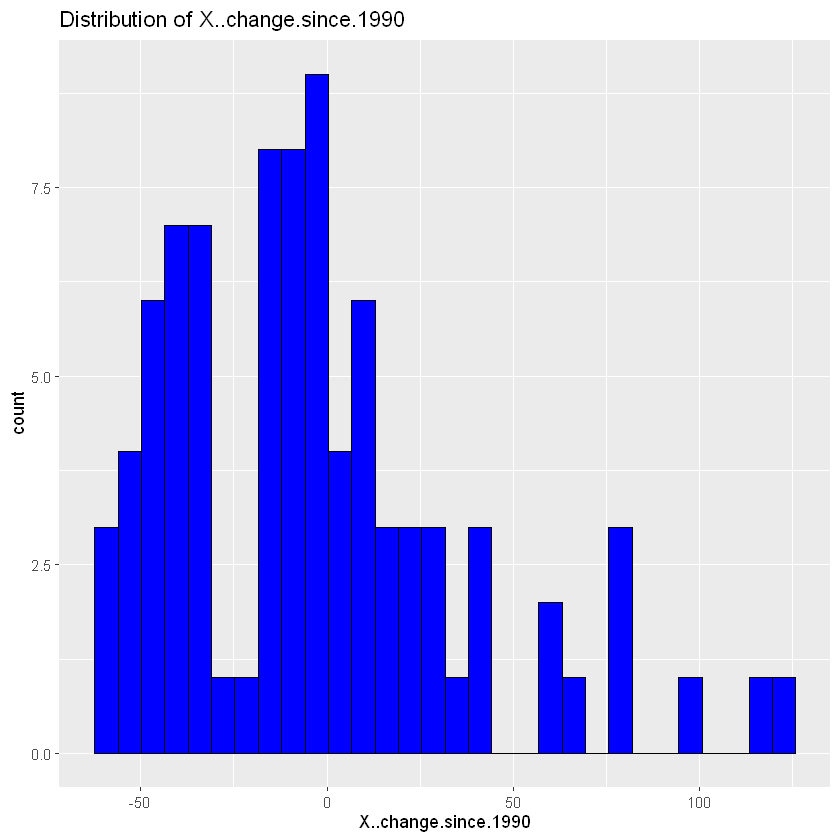

In [419]:
library(ggplot2)

ggplot(df, aes(x = X..change.since.1990)) +
  geom_histogram(bins = 30, fill = "blue", color = "black") +
  ggtitle("Distribution of X..change.since.1990")

Warning message:
"Removed 99 rows containing non-finite outside the scale range (`stat_bin()`)."


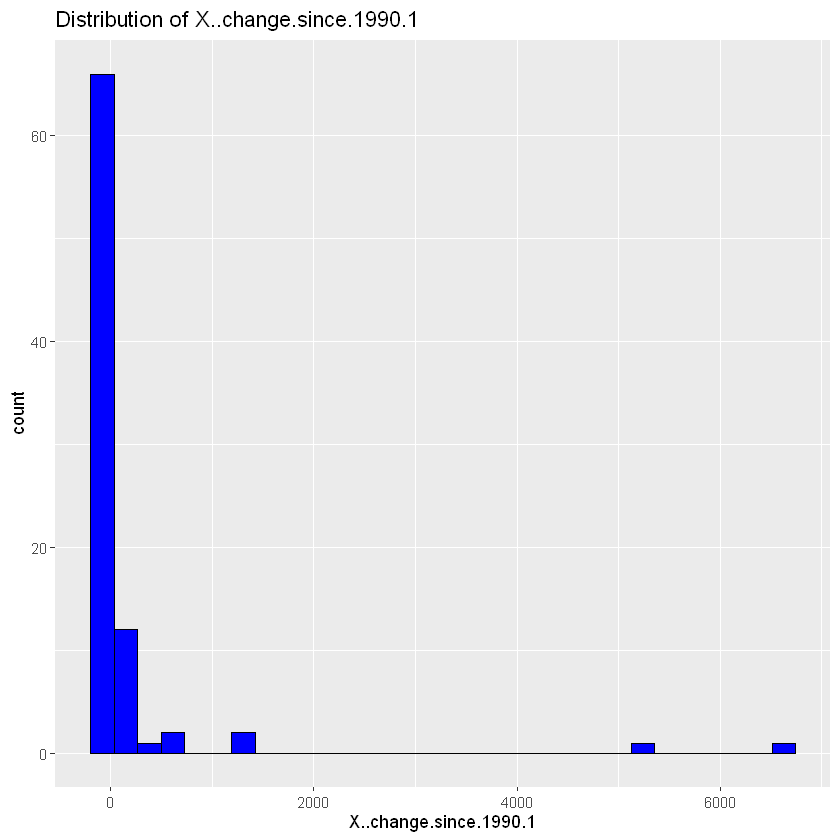

In [420]:
library(ggplot2)

ggplot(df, aes(x = X..change.since.1990.1)) +
  geom_histogram(bins = 30, fill = "blue", color = "black") +
  ggtitle("Distribution of X..change.since.1990.1")

In [421]:
#introduce library moments that assists in skewness
library(moments)

skewness(df$X..change.since.1990, na.rm = TRUE)
#moderately right-skewed

[1] 1.002951

In [422]:
skewness(df$X..change.since.1990.1, na.rm = TRUE)
#highly right-skewed, extreme outliers

[1] 5.904946

In [423]:
#Due to outliers, median is suitable
mdn.XChange <- median(df$X..change.since.1990, na.rm = TRUE)
df$X..change.since.1990[is.na(df$X..change.since.1990)] <- mdn.XChange

In [424]:
#Due to outliers, median is suitable
mdn.XChange.1 <- median(df$X..change.since.1990.1, na.rm = TRUE)
df$X..change.since.1990.1[is.na(df$X..change.since.1990.1)] <- mdn.XChange.1

In [426]:
#Transformation due to extreme skewness
df$X..change.since.1990.1 <- log1p(df$X..change.since.1990.1)

In [427]:
skewness(df$X..change.since.1990.1, na.rm = TRUE)

[1] -1.242347

In [428]:
#Validating the data
colSums(is.na(df))

Country    latest.year.available            CH4.emissions 
                       0                        0                        0 
CH4.emissions.per.capita     X..change.since.1990            N2O.emissions 
                       0                        0                        0 
N2O.emissions.per.capita   X..change.since.1990.1 
                       0                      151

In [429]:
df

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,X..change.since.1990,N2O.emissions,N2O.emissions.per.capita,X..change.since.1990.1
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Afghanistan,2005,10.16,0.42,-7.035,5.94,0.24,NaN
Albania,1994,2.14,0.68,-7.035,0.29,0.09,NaN
Algeria,2000,32.92,1.06,-7.035,6.50,0.21,NaN
Angola,2005,19.93,1.11,-7.035,13.87,0.77,NaN
Antigua and Barbuda,2000,0.14,1.83,43.740,0.08,1.08,2.257182
Argentina,2000,84.85,2.29,10.500,67.50,1.82,1.491181
Armenia,2010,2.26,0.76,-28.660,0.48,0.16,1.829090
Australia,2012,111.71,4.88,-3.020,25.78,1.13,1.552657
Austria,2012,5.31,0.63,-36.320,5.22,0.62,NaN


In [430]:
glimpse(df)

Rows: 184
Columns: 8
$ Country                  <chr> "Afghanistan", "Albania", "Algeria", "Angola"…
$ latest.year.available    <int> 2005, 1994, 2000, 2005, 2000, 2000, 2010, 201…
$ CH4.emissions            <dbl> 10.16, 2.14, 32.92, 19.93, 0.14, 84.85, 2.26,…
$ CH4.emissions.per.capita <dbl> 0.42, 0.68, 1.06, 1.11, 1.83, 2.29, 0.76, 4.8…
$ X..change.since.1990     <dbl> -7.035, -7.035, -7.035, -7.035, 43.740, 10.50…
$ N2O.emissions            <dbl> 5.94, 0.29, 6.50, 13.87, 0.08, 67.50, 0.48, 2…
$ N2O.emissions.per.capita <dbl> 0.24, 0.09, 0.21, 0.77, 1.08, 1.82, 0.16, 1.1…
$ X..change.since.1990.1   <dbl> NaN, NaN, NaN, NaN, 2.257182, 1.491181, 1.829…


In [431]:
#Basic descriptive statistics
summary(df)

   Country          latest.year.available CH4.emissions    
 Length:184         Min.   :1990          Min.   :  0.000  
 Class :character   1st Qu.:2000          1st Qu.:  1.290  
 Mode  :character   Median :2000          Median :  5.075  
                    Mean   :2003          Mean   : 30.878  
                    3rd Qu.:2010          3rd Qu.: 20.430  
                    Max.   :2012          Max.   :932.860  
                                                           
 CH4.emissions.per.capita X..change.since.1990 N2O.emissions   
 Min.   :  0.0200         Min.   :-59.240      Min.   :  0.00  
 1st Qu.:  0.5475         1st Qu.: -7.035      1st Qu.:  0.45  
 Median :  0.8000         Median : -7.035      Median :  3.19  
 Mean   :  3.0856         Mean   : -5.091      Mean   : 17.04  
 3rd Qu.:  1.2950         3rd Qu.: -7.035      3rd Qu.: 11.93  
 Max.   :309.1000         Max.   :122.720      Max.   :395.79  
                                                               
 N2O.emi

In [446]:
#tabular visualization
df_stats<- df%>%
summarize(
    Mean_df = mean(CH4.emissions),
    Variance_df = var(CH4.emissions),
    N_Observations = n()
  )
df_stats

Mean_df,Variance_df,N_Observations
<dbl>,<dbl>,<int>
30.87837,9454.304,184


In [448]:
regional_summary<-df%>%group_by(Country) %>%
  summarize(
    Avg_Emission = mean(CH4.emissions)
  ) %>%
  arrange(desc(Avg_Emission))

print(regional_summary)

# A tibble: 184 × 2
   Country                  Avg_Emission
   <chr>                           <dbl>
 1 China                           933. 
 2 United States of America        552. 
 3 Russian Federation              503. 
 4 India                           407. 
 5 Brazil                          316. 
 6 Indonesia                       236. 
 7 Mexico                          188. 
 8 Australia                       112. 
 9 Canada                           90.6
10 Uzbekistan                       89.4
# ℹ 174 more rows


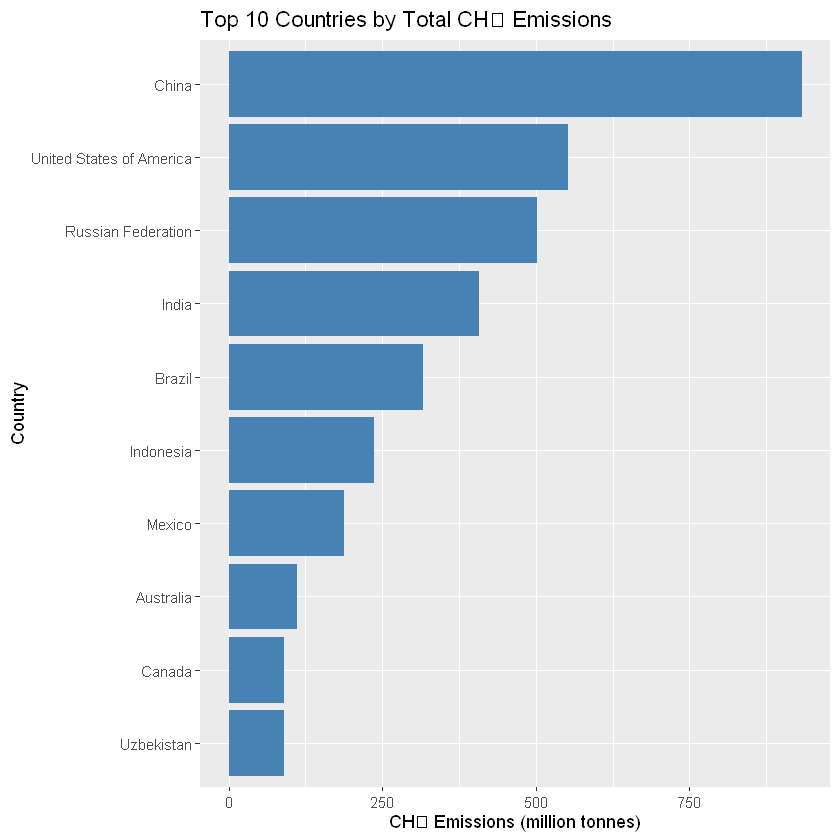

In [449]:
top_ch4 <- df %>% 
  arrange(desc(CH4.emissions)) %>% 
  head(10)

ggplot(top_ch4, aes(x = reorder(Country, CH4.emissions), y = CH4.emissions)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  coord_flip() +
  labs(title = "Top 10 Countries by Total CH₄ Emissions",
       x = "Country", y = "CH₄ Emissions (million tonnes)")


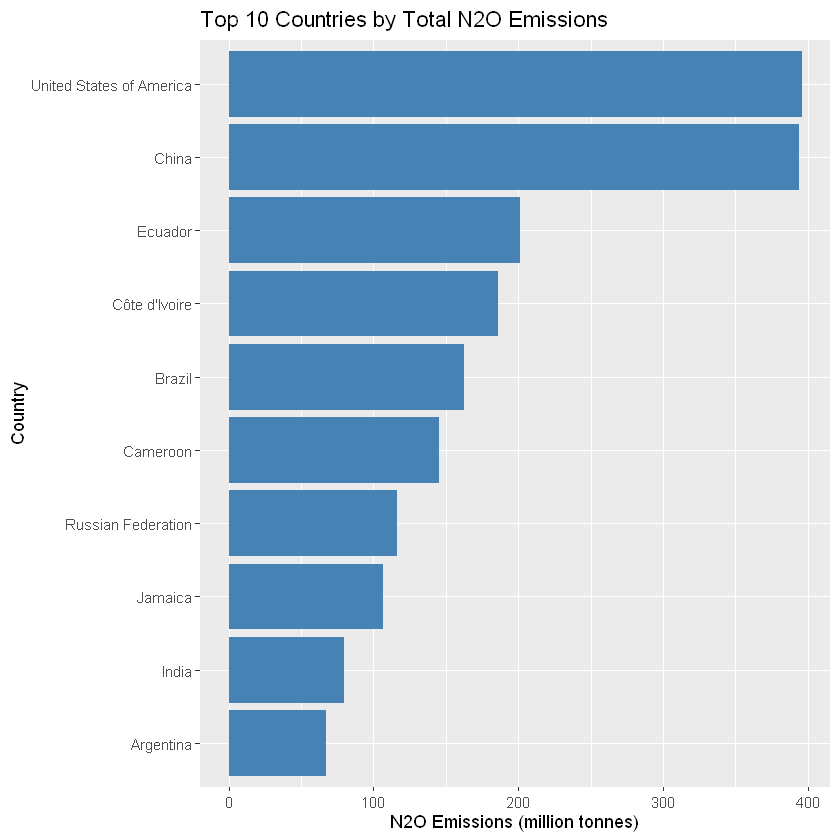

In [450]:
top_ch4 <- df %>% 
  arrange(desc(N2O.emissions)) %>% 
  head(10)

ggplot(top_ch4, aes(x = reorder(Country, N2O.emissions), y = N2O.emissions)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  coord_flip() +
  labs(title = "Top 10 Countries by Total N2O Emissions",
       x = "Country", y = "N2O Emissions (million tonnes)")


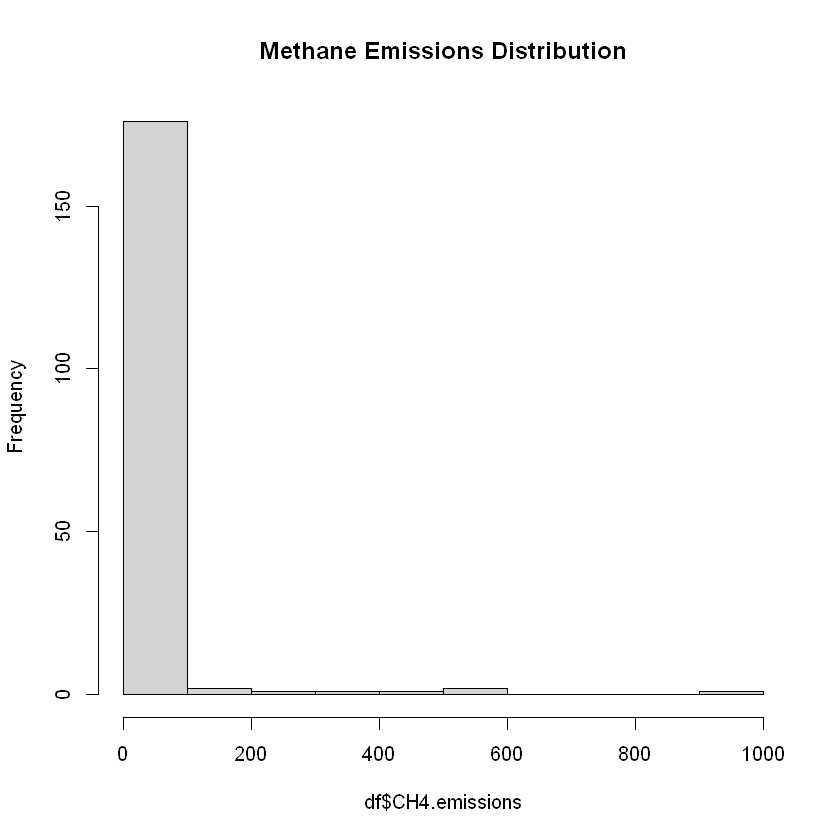

In [451]:
hist(df$CH4.emissions, main="Methane Emissions Distribution")

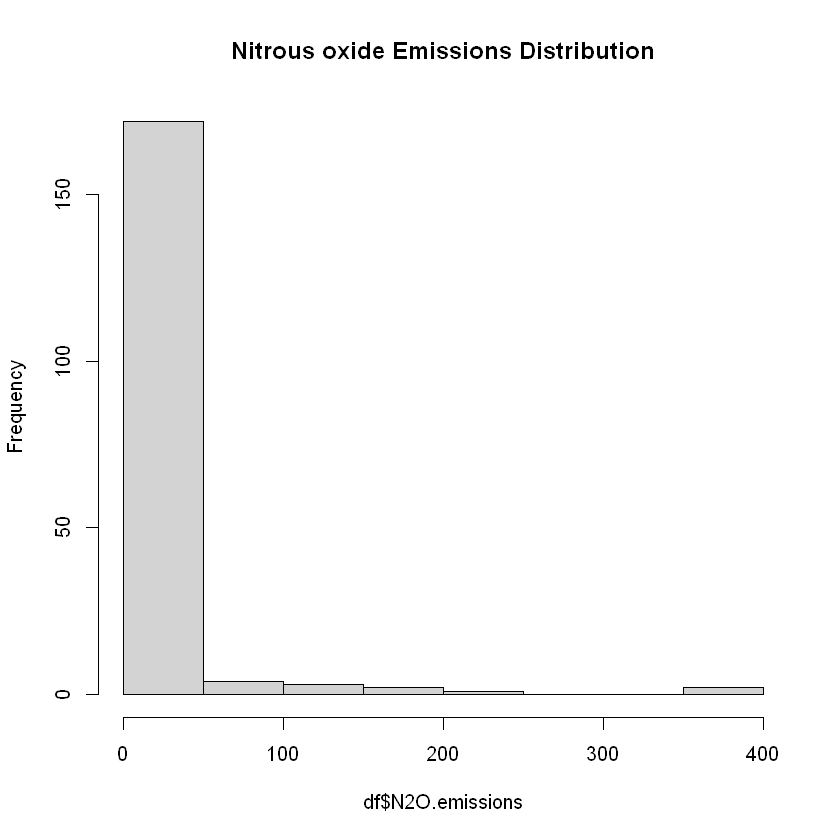

In [452]:
hist(df$N2O.emissions, main="Nitrous oxide Emissions Distribution")

In [453]:
#Feature Engineering , new variable
df$Total_Emissions <- df$CH4.emissions + df$N2O.emissions

In [454]:
head(df)

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,X..change.since.1990,N2O.emissions,N2O.emissions.per.capita,X..change.since.1990.1,Total_Emissions
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Afghanistan,2005,10.16,0.42,-7.035,5.94,0.24,NaN,16.10
Albania,1994,2.14,0.68,-7.035,0.29,0.09,NaN,2.43
Algeria,2000,32.92,1.06,-7.035,6.50,0.21,NaN,39.42
Angola,2005,19.93,1.11,-7.035,13.87,0.77,NaN,33.80
Antigua and Barbuda,2000,0.14,1.83,43.740,0.08,1.08,2.257182,0.22
Argentina,2000,84.85,2.29,10.500,67.50,1.82,1.491181,152.35


In [455]:
lowest_CH4 <- min(df$CH4.emissions, na.rm = TRUE)
highest_CH4 <- max(df$CH4.emissions, na.rm = TRUE)
print(lowest_CH4 )

[1] 0


In [456]:
print(highest_CH4)

[1] 932.86


In [457]:
lowest_N2O <- min(df$N2O.emissions, na.rm = TRUE)
highest_N2O <- max(df$N2O.emissions, na.rm = TRUE)
print(lowest_N2O )

[1] 0


In [458]:
print(highest_N2O)

[1] 395.79


In [459]:
lowest_tot <- min(df$Total_Emissions, na.rm = TRUE)
highest_tot <- max(df$Total_Emissions, na.rm = TRUE)
print(lowest_tot )

[1] 0


In [460]:
print(highest_tot)

[1] 1326.96


In [461]:
df <- df %>%
  mutate(Methane_Safety = case_when(
    CH4.emissions >= 0.00 & CH4.emissions <=50  ~ "Safe",
    CH4.emissions >= 51 & CH4.emissions <= 950 ~ "Dangerous",
  ))

In [462]:
df <- df %>%
  mutate(Nitrous_Oxide_Safety = case_when(
    N2O.emissions >= 0.00 & N2O.emissions <= 18 ~ "Safe",
    N2O.emissions >=19  & N2O.emissions <= 400 ~ "Dangerous",
  ))

In [463]:
df <- df %>%
  mutate(Overall_Safety = case_when(
    Total_Emissions >= 0.00 & Total_Emissions <= 68 ~ "Safe",
    Total_Emissions >= 69 & Total_Emissions <= 1327.00 ~ "Dangerous",
  ))

In [465]:
df

Country,latest.year.available,CH4.emissions,CH4.emissions.per.capita,X..change.since.1990,N2O.emissions,N2O.emissions.per.capita,X..change.since.1990.1,Total_Emissions,Methane_Safety,Nitrous_Oxide_Safety,Overall_Safety
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
Afghanistan,2005,10.16,0.42,-7.035,5.94,0.24,NaN,16.10,Safe,Safe,Safe
Albania,1994,2.14,0.68,-7.035,0.29,0.09,NaN,2.43,Safe,Safe,Safe
Algeria,2000,32.92,1.06,-7.035,6.50,0.21,NaN,39.42,Safe,Safe,Safe
Angola,2005,19.93,1.11,-7.035,13.87,0.77,NaN,33.80,Safe,Safe,Safe
Antigua and Barbuda,2000,0.14,1.83,43.740,0.08,1.08,2.257182,0.22,Safe,Safe,Safe
Argentina,2000,84.85,2.29,10.500,67.50,1.82,1.491181,152.35,Dangerous,Dangerous,Dangerous
Armenia,2010,2.26,0.76,-28.660,0.48,0.16,1.829090,2.74,Safe,Safe,Safe
Australia,2012,111.71,4.88,-3.020,25.78,1.13,1.552657,137.49,Dangerous,Dangerous,Dangerous
Austria,2012,5.31,0.63,-36.320,5.22,0.62,NaN,10.53,Safe,Safe,Safe
